# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
training_samples_size = 1000
training_samples = torch.normal( 0.0,  0.5, (training_samples_size, 1))

Training process follows standard energy based model training as per [Yu et. al 2020](https://arxiv.org/pdf/1903.08689)

In [3]:
class MLP(nn.Module):
    def __init__(self, x_dim, t_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim + t_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=-1)
        return self.net(xt)

Training follows the denoising score matching objective
$$L(\theta) = E[||\epsilon + \sigma_t \nabla_x f_{\theta}(x + \sigma_t \epsilon)||^2]$$

In [45]:
n_epochs = 15000
n_timesteps = 100
batch_size = 128
beta_min = 1e-4
beta_max = 2e-2

betas = torch.linspace(beta_min, beta_max, n_timesteps)
alphas = 1 - betas
alpha_cumprod = torch.cumprod(alphas, dim=0)

model = MLP(x_dim=1, t_dim=1, hidden_dim=64, output_dim=1)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(n_epochs):

    t = torch.randint(0, n_timesteps, (batch_size, 1))
    beta_t = betas[t]
    alpha_bar_t = alpha_cumprod[t]
    x_0 = training_samples[torch.randint(0, training_samples.size(0), (batch_size,))]
    noise = torch.randn_like(x_0)

    x_t = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1 - alpha_bar_t) * noise
    x_t = x_t.requires_grad_(True)

    # f (x + sigma epsilon)
    energy = model(x_t, t)
    # nabla f (x + sigma epsilon)
    pred_score = torch.autograd.grad(energy.sum(), x_t, create_graph=True)[0]

    loss = torch.mean((noise + pred_score * torch.sqrt(1 - alpha_bar_t)) ** 2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f" loss at epoch {epoch}: {loss.item():.2f}")

 loss at epoch 0: 1.01
 loss at epoch 100: 1.15


 loss at epoch 200: 0.58
 loss at epoch 300: 0.67
 loss at epoch 400: 0.74
 loss at epoch 500: 0.76
 loss at epoch 600: 0.63
 loss at epoch 700: 0.77
 loss at epoch 800: 0.64
 loss at epoch 900: 0.68
 loss at epoch 1000: 0.60
 loss at epoch 1100: 0.55
 loss at epoch 1200: 0.70
 loss at epoch 1300: 0.56
 loss at epoch 1400: 0.71
 loss at epoch 1500: 0.56
 loss at epoch 1600: 0.52
 loss at epoch 1700: 0.67
 loss at epoch 1800: 0.79
 loss at epoch 1900: 0.54
 loss at epoch 2000: 0.57
 loss at epoch 2100: 0.70
 loss at epoch 2200: 0.66
 loss at epoch 2300: 0.68
 loss at epoch 2400: 0.62
 loss at epoch 2500: 0.60
 loss at epoch 2600: 0.81
 loss at epoch 2700: 0.63
 loss at epoch 2800: 0.55
 loss at epoch 2900: 0.70
 loss at epoch 3000: 0.66
 loss at epoch 3100: 0.53
 loss at epoch 3200: 0.59
 loss at epoch 3300: 0.85
 loss at epoch 3400: 0.56
 loss at epoch 3500: 0.55
 loss at epoch 3600: 0.61
 loss at epoch 3700: 0.57
 loss at epoch 3800: 0.51
 loss at epoch 3900: 0.55
 loss at epoch 4000:

Sampling follows annealed MCMC

Input:
- Transition kernels $k_t(· | ·)$
- Initial distribution $p_T(·)$
- Number of steps $N$

Sampling steps:
- Initialize $x_T \sim p_T(·)$
- for $t = T, T-1, ... ,  0$ do
    - for $i = 1, ... ,  N$ do
        - $x_t \sim k_t(· | x_t)$
    - end for
    - $x_{t-1} = x_t$
- end for
```

In [63]:
n_langevin_steps = 15

x = torch.randn_like(training_samples).requires_grad_(True)
ones = torch.ones_like(training_samples) 

for t in reversed(range(n_timesteps)):
    for i in range(n_langevin_steps):

        step_size =  betas[t]
        alpha_bar_t = alpha_cumprod[t]

        t_batch = t * ones

        # compute nabla f
        energy = model(x, t_batch)
        pred_score = torch.autograd.grad(energy.sum(), x)[0]

        # ULA algorithm
        mean = x + step_size * pred_score
        std = torch.sqrt(2* step_size)

        x = mean + ( torch.randn_like(x) * std )

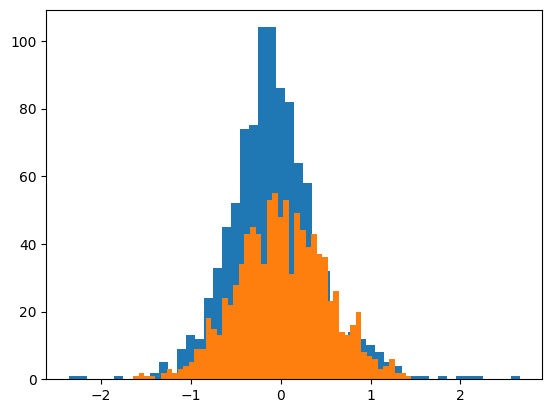

In [64]:
_ = plt.hist(x.detach().numpy(), bins = 50)
_ = plt.hist(training_samples.detach().numpy(), bins=50)